In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random
from sklearn.model_selection import KFold

/home/fakoor/Desktop/llama_persianmind/w_model/w_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

# train and test functions

In [3]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses


def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs).logits
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

## tiny_aug_Kfold

In [4]:
reset_seed(42)

whisper_tiny_processor = WhisperProcessor.from_pretrained('w_tiny')


emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [6]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 2958 2959 2960]
  Test:  index=[   7   12   29   30   32   43   44   45   51   56   63   67   70   73
   80   87   93   96  102  104  108  111  120  124  134  135  139  141
  144  149  152  162  168  170  173  174  175  177  178  183  184  188
  192  194  196  199  203  210  211  212  218  221  226  231  233  239
  246  251  254  256  257  270  272  282  283  289  291  296  298  309
  313  314  318  321  322  324  331  332  351  354  365  366  367  368
  387  393  402  407  408  410  411  414  415  420  422  423  430  432
  433  436  439  443  450  457  460  463  464  471  478  479  485  486
  495  498  506  507  509  511  521  527  528  532  533  535  543  544
  554  555  557  564  565  567  568  572  581  594  598  599  602  605
  610  612  637  642  644  650  651  670  676  677  678  679  685  693
  695  700  705  727  736  741  742  744  746  748  761  764  765  772
  781  783  785  789  807  809  811  817  819  829  838  839  840  842
  8

In [7]:
(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [8]:
################# Train_features
trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

################# Train_labels
trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

################# Test_features
testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

################# Test_labels
testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

################## Train_names
trainF1names = [value for index, value in enumerate(file_names) if index in train_index1]
trainF2names = [value for index, value in enumerate(file_names) if index in train_index2]
trainF3names = [value for index, value in enumerate(file_names) if index in train_index3]
trainF4names = [value for index, value in enumerate(file_names) if index in train_index4]
trainF5names = [value for index, value in enumerate(file_names) if index in train_index5]

################# Train_paths
trainF1paths = [value for index, value in enumerate(file_paths) if index in train_index1]
trainF2paths = [value for index, value in enumerate(file_paths) if index in train_index2]
trainF3paths = [value for index, value in enumerate(file_paths) if index in train_index3]
trainF4paths = [value for index, value in enumerate(file_paths) if index in train_index4]
trainF5paths = [value for index, value in enumerate(file_paths) if index in train_index5]

################# Test_names
testF1names = [value for index, value in enumerate(file_names) if index in test_index1]
testF2names = [value for index, value in enumerate(file_names) if index in test_index2]
testF3names = [value for index, value in enumerate(file_names) if index in test_index3]
testF4names = [value for index, value in enumerate(file_names) if index in test_index4]
testF5names = [value for index, value in enumerate(file_names) if index in test_index5]

################# Test_paths
testF1paths = [value for index, value in enumerate(file_paths) if index in test_index1]
testF2paths = [value for index, value in enumerate(file_paths) if index in test_index2]
testF3paths = [value for index, value in enumerate(file_paths) if index in test_index3]
testF4paths = [value for index, value in enumerate(file_paths) if index in test_index4]
testF5paths = [value for index, value in enumerate(file_paths) if index in test_index5]

In [9]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels, file_names=None, file_paths=None):
        self.features = features
        self.labels = labels
        self.index = list(range(len(labels)))
        self.filename = file_names
        self.filepath = file_paths


    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]]),  # Convert to PyTorch tensor if not already
            'name' : self.filename[index],
            'path' : self.filepath[index],
            'gender': self.filename[index][0],
            'index': self.index[index]
        }


        return sample


Fold1train = AudioDataSet(trainF1features, trainF1labels, trainF1names, trainF1paths)
Fold1test = AudioDataSet(testF1features, testF1labels, testF1names, testF1paths)

Fold2train = AudioDataSet(trainF2features, trainF2labels, trainF2names, trainF2paths)
Fold2test = AudioDataSet(testF2features, testF2labels, testF2names, testF2paths)

Fold3train = AudioDataSet(trainF3features, trainF3labels, trainF3names, trainF3paths)
Fold3test = AudioDataSet(testF3features, testF3labels, testF3names, testF3paths)

Fold4train = AudioDataSet(trainF4features, trainF4labels, trainF4names, trainF4paths)
Fold4test = AudioDataSet(testF4features, testF4labels, testF4names, testF4paths)

Fold5train = AudioDataSet(trainF5features, trainF5labels, trainF5names, trainF5paths)
Fold5test = AudioDataSet(testF5features, testF5labels, testF5names, testF5paths)

In [10]:
# Fold1train_indices = list(map(lambda x: x['index'], Fold1train))
# Fold2train_indices = list(map(lambda x: x['index'], Fold2train))
# Fold3train_indices = list(map(lambda x: x['index'], Fold3train))
# Fold4train_indices = list(map(lambda x: x['index'], Fold4train))
# Fold5train_indices = list(map(lambda x: x['index'], Fold5train))

In [11]:
folds_trains = [Fold1train, Fold2train, Fold3train, Fold4train, Fold5train]
folds_vals = [Fold1test, Fold2test, Fold3test, Fold4test, Fold5test]
folds_indices = [train_index1, train_index2, train_index3, train_index4, train_index5]

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 48.09 seconds, Training Loss:  0.97, Validation Loss: 0.65, Validation Accuracy:  0.76


Epoch: 2 finished in 47.88 seconds, Training Loss:  0.72, Validation Loss: 0.69, Validation Accuracy:  0.76


Epoch: 3 finished in 47.24 seconds, Training Loss:  0.66, Validation Loss: 0.83, Validation Accuracy:  0.68


Epoch: 4 finished in 47.94 seconds, Training Loss:  0.62, Validation Loss: 0.61, Validation Accuracy:  0.76


...

Epoch: 36 finished in 47.14 seconds, Training Loss:  0.40, Validation Loss: 0.63, Validation Accuracy:  0.79


Epoch: 37 finished in 47.27 seconds, Training Loss:  0.40, Validation Loss: 0.58, Validation Accuracy:  0.78


Epoch: 38 finished in 47.65 seconds, Training Loss:  0.39, Validation Loss: 0.51, Validation Accuracy:  0.82


Epoch: 39 finished in 47.61 seconds, Training Loss:  0.38, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 40 finished in 47.96 seconds, Training Loss:  0.38, Validation Loss: 0.67, Validation Accuracy:  0.78
Each epoch took 47.06 seconds in average.


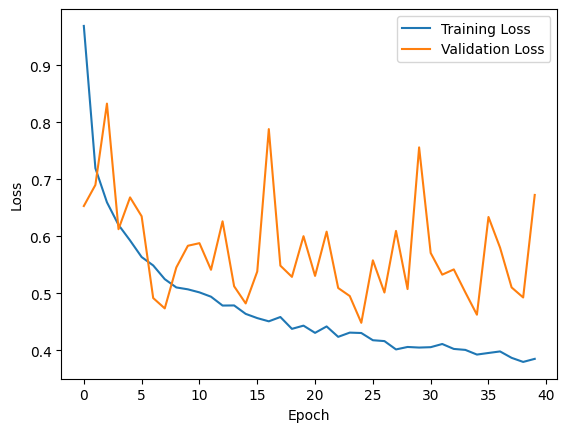

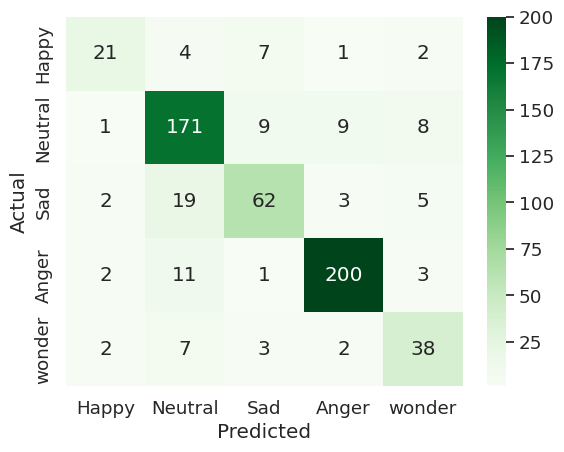

Testing finished with Loss:  0.45 | U_Accuracy:  0.76 | W_Accuracy:  0.83 | Precision:  0.83 | Recall:  0.83 | f1:  0.83
Accuracy per class:
Class 0: 0.6
Class 1: 0.8636363636363636
Class 2: 0.6813186813186813
Class 3: 0.9216589861751152
Class 4: 0.7307692307692307


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 46.09 seconds, Training Loss:  0.95, Validation Loss: 0.73, Validation Accuracy:  0.72


Epoch: 2 finished in 45.89 seconds, Training Loss:  0.70, Validation Loss: 0.77, Validation Accuracy:  0.73


Epoch: 3 finished in 46.35 seconds, Training Loss:  0.64, Validation Loss: 0.82, Validation Accuracy:  0.72


...

Epoch: 36 finished in 46.96 seconds, Training Loss:  0.38, Validation Loss: 0.60, Validation Accuracy:  0.80


Epoch: 37 finished in 46.69 seconds, Training Loss:  0.36, Validation Loss: 0.58, Validation Accuracy:  0.81


Epoch: 38 finished in 45.37 seconds, Training Loss:  0.37, Validation Loss: 0.65, Validation Accuracy:  0.79


Epoch: 39 finished in 44.90 seconds, Training Loss:  0.37, Validation Loss: 0.60, Validation Accuracy:  0.78


Epoch: 40 finished in 44.38 seconds, Training Loss:  0.37, Validation Loss: 0.58, Validation Accuracy:  0.80
Each epoch took 45.39 seconds in average.


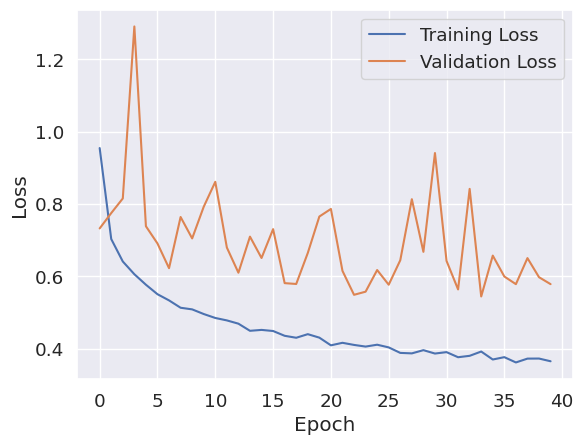

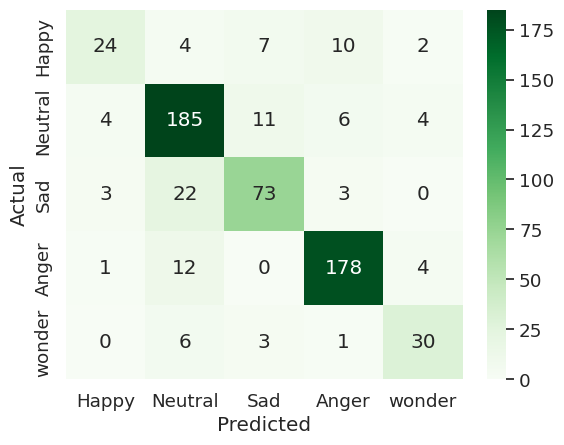

Testing finished with Loss:  0.54 | U_Accuracy:  0.76 | W_Accuracy:  0.83 | Precision:  0.82 | Recall:  0.83 | f1:  0.82
Accuracy per class:
Class 0: 0.5106382978723404
Class 1: 0.8809523809523809
Class 2: 0.7227722772277227
Class 3: 0.9128205128205128
Class 4: 0.75


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 44.66 seconds, Training Loss:  0.93, Validation Loss: 0.80, Validation Accuracy:  0.69


Epoch: 2 finished in 44.41 seconds, Training Loss:  0.70, Validation Loss: 0.73, Validation Accuracy:  0.77


Epoch: 3 finished in 44.65 seconds, Training Loss:  0.62, Validation Loss: 0.62, Validation Accuracy:  0.79


...

Epoch: 36 finished in 44.87 seconds, Training Loss:  0.37, Validation Loss: 0.58, Validation Accuracy:  0.80


Epoch: 37 finished in 44.91 seconds, Training Loss:  0.38, Validation Loss: 0.75, Validation Accuracy:  0.76


Epoch: 38 finished in 44.77 seconds, Training Loss:  0.37, Validation Loss: 0.50, Validation Accuracy:  0.84


Epoch: 39 finished in 44.85 seconds, Training Loss:  0.37, Validation Loss: 0.74, Validation Accuracy:  0.76


Epoch: 40 finished in 44.77 seconds, Training Loss:  0.37, Validation Loss: 0.50, Validation Accuracy:  0.83
Each epoch took 45.24 seconds in average.


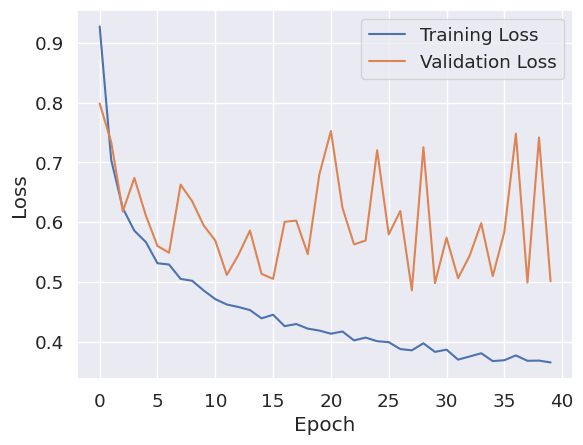

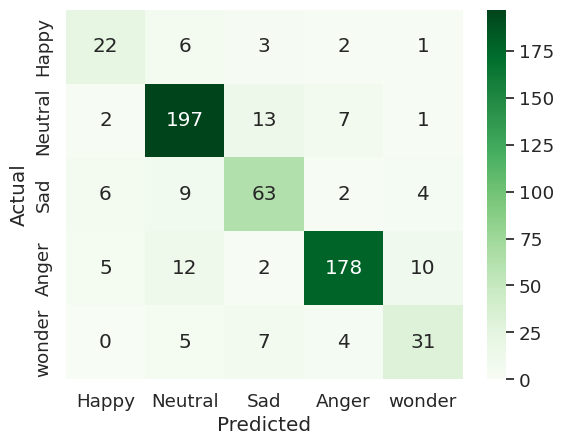

Testing finished with Loss:  0.49 | U_Accuracy:  0.76 | W_Accuracy:  0.83 | Precision:  0.83 | Recall:  0.83 | f1:  0.83
Accuracy per class:
Class 0: 0.6470588235294118
Class 1: 0.8954545454545455
Class 2: 0.75
Class 3: 0.8599033816425121
Class 4: 0.6595744680851063


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 43.79 seconds, Training Loss:  0.92, Validation Loss: 0.78, Validation Accuracy:  0.71


Epoch: 2 finished in 43.81 seconds, Training Loss:  0.70, Validation Loss: 0.76, Validation Accuracy:  0.71


Epoch: 3 finished in 44.30 seconds, Training Loss:  0.63, Validation Loss: 0.74, Validation Accuracy:  0.72


...

Epoch: 36 finished in 44.78 seconds, Training Loss:  0.37, Validation Loss: 0.59, Validation Accuracy:  0.80


Epoch: 37 finished in 44.80 seconds, Training Loss:  0.36, Validation Loss: 0.54, Validation Accuracy:  0.81


Epoch: 38 finished in 44.81 seconds, Training Loss:  0.37, Validation Loss: 0.97, Validation Accuracy:  0.71


Epoch: 39 finished in 44.83 seconds, Training Loss:  0.36, Validation Loss: 0.63, Validation Accuracy:  0.79


Epoch: 40 finished in 44.87 seconds, Training Loss:  0.35, Validation Loss: 0.53, Validation Accuracy:  0.82
Each epoch took 44.59 seconds in average.


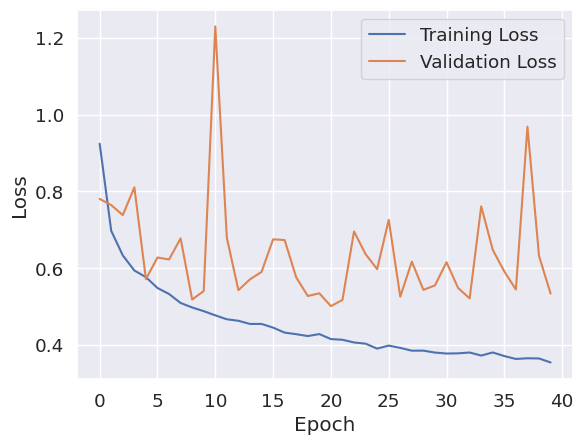

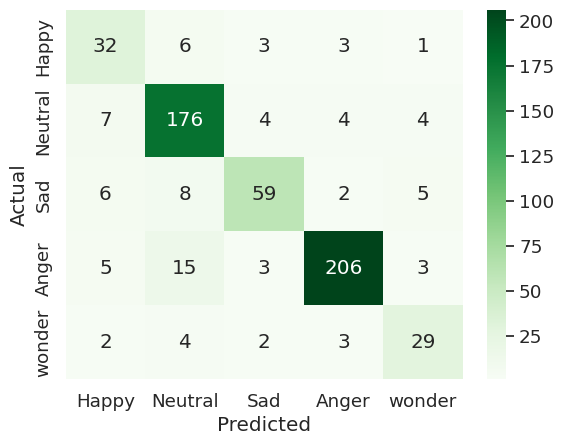

Testing finished with Loss:  0.50 | U_Accuracy:  0.79 | W_Accuracy:  0.85 | Precision:  0.85 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.7111111111111111
Class 1: 0.9025641025641026
Class 2: 0.7375
Class 3: 0.8879310344827587
Class 4: 0.725


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 44.25 seconds, Training Loss:  0.93, Validation Loss: 0.73, Validation Accuracy:  0.72


Epoch: 2 finished in 44.28 seconds, Training Loss:  0.72, Validation Loss: 0.83, Validation Accuracy:  0.71


Epoch: 3 finished in 44.28 seconds, Training Loss:  0.64, Validation Loss: 0.69, Validation Accuracy:  0.74


...

Epoch: 36 finished in 45.06 seconds, Training Loss:  0.38, Validation Loss: 0.67, Validation Accuracy:  0.81


Epoch: 37 finished in 44.92 seconds, Training Loss:  0.38, Validation Loss: 0.66, Validation Accuracy:  0.78


Epoch: 38 finished in 45.06 seconds, Training Loss:  0.37, Validation Loss: 0.77, Validation Accuracy:  0.77


Epoch: 39 finished in 45.02 seconds, Training Loss:  0.38, Validation Loss: 0.70, Validation Accuracy:  0.74


Epoch: 40 finished in 45.04 seconds, Training Loss:  0.37, Validation Loss: 0.69, Validation Accuracy:  0.80
Each epoch took 44.75 seconds in average.


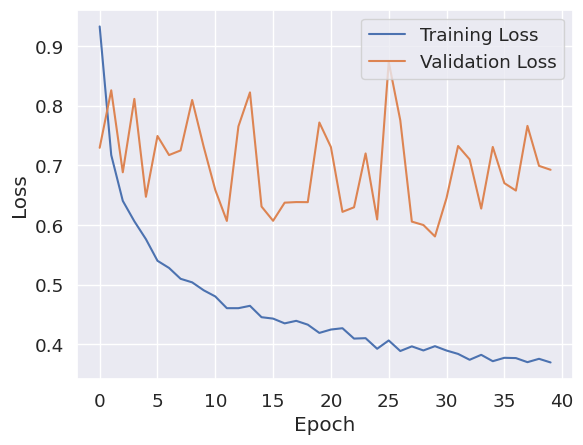

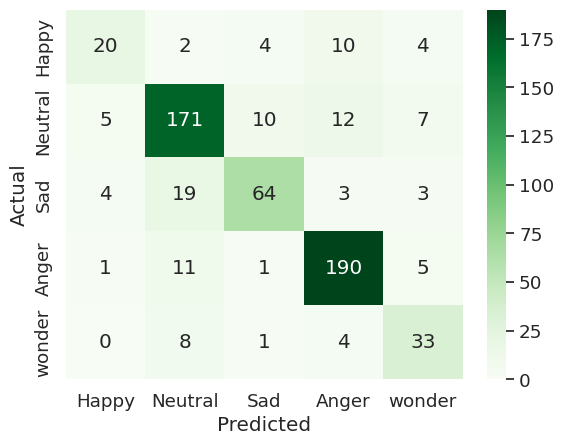

Testing finished with Loss:  0.58 | U_Accuracy:  0.73 | W_Accuracy:  0.81 | Precision:  0.81 | Recall:  0.81 | f1:  0.80
Accuracy per class:
Class 0: 0.5
Class 1: 0.8341463414634146
Class 2: 0.6881720430107527
Class 3: 0.9134615384615384
Class 4: 0.717391304347826


In [12]:
reset_seed(42)
counter = 1
loader_lists = []

for trainset_indices, trainset, valset in zip(folds_indices, folds_trains, folds_vals):
    audios_to_aug = [audio for (ind,audio) in enumerate(audios) if ind in trainset_indices]
    audio_gender_to_aug = [name[0] for (ind,name) in enumerate(file_names) if ind in trainset_indices]
    audio_emo_to_aug = [emotion for (ind,emotion) in enumerate(emotions) if ind in trainset_indices]

    segments ={}


    for emotion in ['H', 'W', 'S', 'A', 'N']:

        audiosF1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosF2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosM1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]
        audiosM2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]

        segments[emotion] = [(audiosF1, audiosF2), (audiosM1, audiosM2)]

    
    augmented_audios = []
    augmented_labels = []
    augmented_emotions = []

    augmentation_need = {
        'H': 9,
        'W': 9,
        'S': 4,
        'A': 1,
        'N': 1
        }
    
    for category in segments:
        for gender_segments in segments[category]:
            for audio in gender_segments[0]:
                choice = random.sample(gender_segments[1], augmentation_need[category])
                for ch in choice:
                    new_speech = np.concatenate((audio, ch))
                    augmented_audios.append(new_speech)
                    augmented_emotions.append(category)
                    augmented_labels.append(emo2num[category])


    augmented_samplerates = []
    augmeted_features = []


    for audio in augmented_audios:

        input_features = whisper_tiny_processor(audio, sampling_rate=16000, return_tensors="pt").input_features

        augmented_samplerates.append(16000)
        augmeted_features.append(input_features.squeeze(0))


    Aug = AudioDataSet(augmeted_features, augmented_labels, [' ']*len(augmeted_features), [' ']*len(augmeted_features))
    concatenated_dataset = ConcatDataset([trainset, Aug])


    train_loader = DataLoader(concatenated_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(valset, batch_size=4, shuffle=False)


    whisper_small_path = 'w_tiny'
    whisper_small = WhisperForAudioClassification.from_pretrained(
        whisper_small_path
    ).to(device)


    for param in whisper_small.parameters():
        param.requires_grad = False

    for param in whisper_small.projector.parameters():
        param.requires_grad = True

    whisper_small.classifier = torch.nn.Linear(256, 5).to(device) # Changing the head to fit our data and problem

    optimizer = torch.optim.Adam(whisper_small.parameters(), lr=0.001)

    training_losses1, valid_losses1 = train(whisper_small, f'whisper_tiny_aug_fold{counter}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)
    

    plt.plot(training_losses1, label='Training Loss')
    plt.plot(valid_losses1, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_small.load_state_dict(torch.load(f'whisper_tiny_aug_fold{counter}.bin'))
    test(whisper_small, torch.nn.CrossEntropyLoss(), val_loader)
    counter += 1

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 264.69 seconds, Training Loss:  0.74, Validation Loss: 0.81, Validation Accuracy:  0.75


Epoch: 2 finished in 265.18 seconds, Training Loss:  0.49, Validation Loss: 0.57, Validation Accuracy:  0.81


Epoch: 3 finished in 265.06 seconds, Training Loss:  0.41, Validation Loss: 0.64, Validation Accuracy:  0.82


Epoch: 4 finished in 265.74 seconds, Training Loss:  0.39, Validation Loss: 0.54, Validation Accuracy:  0.82


...

Epoch: 36 finished in 265.17 seconds, Training Loss:  0.19, Validation Loss: 0.76, Validation Accuracy:  0.78


Epoch: 37 finished in 265.31 seconds, Training Loss:  0.18, Validation Loss: 0.59, Validation Accuracy:  0.83


Epoch: 38 finished in 264.86 seconds, Training Loss:  0.17, Validation Loss: 0.56, Validation Accuracy:  0.84


Epoch: 39 finished in 265.63 seconds, Training Loss:  0.18, Validation Loss: 0.61, Validation Accuracy:  0.83


Epoch: 40 finished in 265.27 seconds, Training Loss:  0.18, Validation Loss: 0.84, Validation Accuracy:  0.81
Each epoch took 265.40 seconds in average.


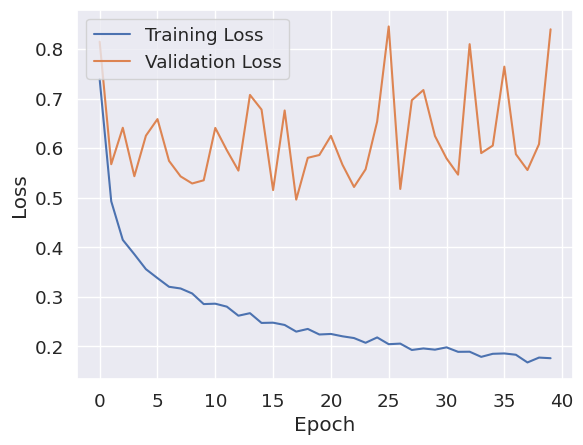

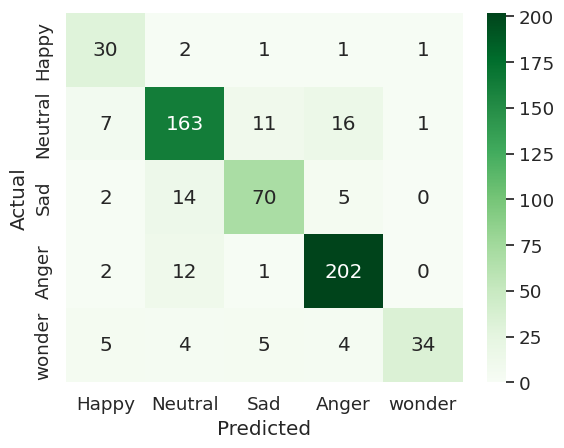

Testing finished with Loss:  0.50 | U_Accuracy:  0.81 | W_Accuracy:  0.84 | Precision:  0.85 | Recall:  0.84 | f1:  0.84
Accuracy per class:
Class 0: 0.8571428571428571
Class 1: 0.8232323232323232
Class 2: 0.7692307692307693
Class 3: 0.9308755760368663
Class 4: 0.6538461538461539


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 263.57 seconds, Training Loss:  0.76, Validation Loss: 0.55, Validation Accuracy:  0.80


Epoch: 2 finished in 264.43 seconds, Training Loss:  0.51, Validation Loss: 0.60, Validation Accuracy:  0.79


Epoch: 3 finished in 264.76 seconds, Training Loss:  0.44, Validation Loss: 0.67, Validation Accuracy:  0.78


...

Epoch: 36 finished in 266.04 seconds, Training Loss:  0.18, Validation Loss: 0.62, Validation Accuracy:  0.84


Epoch: 37 finished in 266.36 seconds, Training Loss:  0.19, Validation Loss: 0.59, Validation Accuracy:  0.85


Epoch: 38 finished in 266.05 seconds, Training Loss:  0.18, Validation Loss: 0.72, Validation Accuracy:  0.81


Epoch: 39 finished in 266.04 seconds, Training Loss:  0.18, Validation Loss: 0.57, Validation Accuracy:  0.85


Epoch: 40 finished in 266.16 seconds, Training Loss:  0.17, Validation Loss: 0.67, Validation Accuracy:  0.83
Each epoch took 265.54 seconds in average.


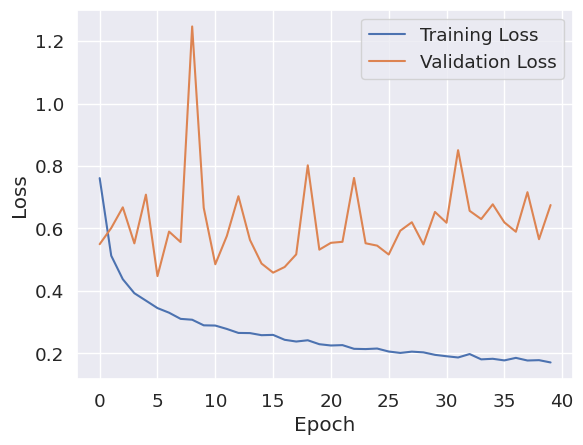

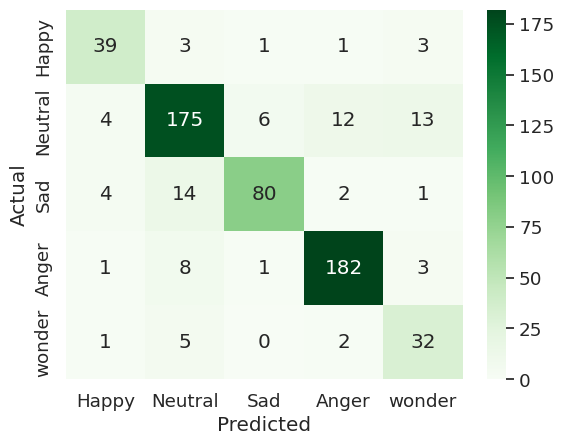

Testing finished with Loss:  0.45 | U_Accuracy:  0.84 | W_Accuracy:  0.86 | Precision:  0.86 | Recall:  0.86 | f1:  0.86
Accuracy per class:
Class 0: 0.8297872340425532
Class 1: 0.8333333333333334
Class 2: 0.7920792079207921
Class 3: 0.9333333333333333
Class 4: 0.8


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 267.69 seconds, Training Loss:  0.75, Validation Loss: 0.63, Validation Accuracy:  0.78


Epoch: 2 finished in 268.77 seconds, Training Loss:  0.50, Validation Loss: 0.44, Validation Accuracy:  0.84


Epoch: 3 finished in 269.36 seconds, Training Loss:  0.43, Validation Loss: 0.62, Validation Accuracy:  0.77


...

Epoch: 36 finished in 268.71 seconds, Training Loss:  0.19, Validation Loss: 0.43, Validation Accuracy:  0.87


Epoch: 37 finished in 268.68 seconds, Training Loss:  0.18, Validation Loss: 0.42, Validation Accuracy:  0.87


Epoch: 38 finished in 268.06 seconds, Training Loss:  0.19, Validation Loss: 0.47, Validation Accuracy:  0.88


Epoch: 39 finished in 269.00 seconds, Training Loss:  0.18, Validation Loss: 0.47, Validation Accuracy:  0.87


Epoch: 40 finished in 269.89 seconds, Training Loss:  0.19, Validation Loss: 0.44, Validation Accuracy:  0.87
Each epoch took 269.09 seconds in average.


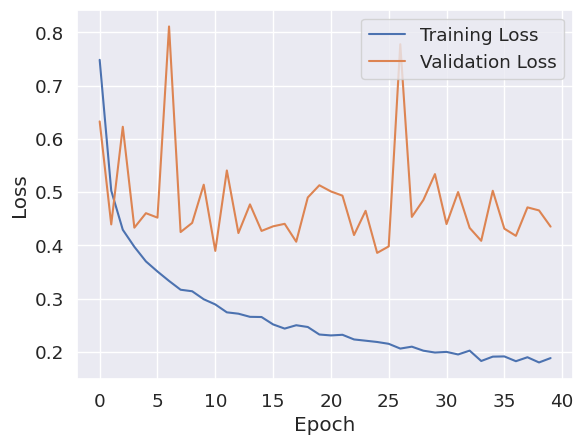

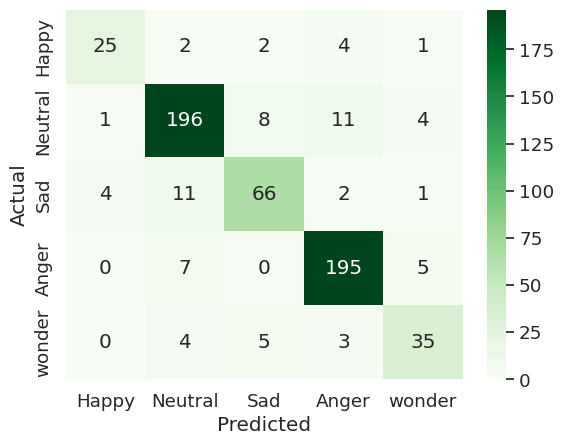

Testing finished with Loss:  0.39 | U_Accuracy:  0.82 | W_Accuracy:  0.87 | Precision:  0.87 | Recall:  0.87 | f1:  0.87
Accuracy per class:
Class 0: 0.7352941176470589
Class 1: 0.8909090909090909
Class 2: 0.7857142857142857
Class 3: 0.9420289855072463
Class 4: 0.7446808510638298


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 266.74 seconds, Training Loss:  0.73, Validation Loss: 0.63, Validation Accuracy:  0.79


Epoch: 2 finished in 267.82 seconds, Training Loss:  0.48, Validation Loss: 0.50, Validation Accuracy:  0.82


Epoch: 3 finished in 268.42 seconds, Training Loss:  0.42, Validation Loss: 0.80, Validation Accuracy:  0.74


...

Epoch: 36 finished in 268.71 seconds, Training Loss:  0.17, Validation Loss: 0.61, Validation Accuracy:  0.84


Epoch: 37 finished in 268.60 seconds, Training Loss:  0.18, Validation Loss: 0.49, Validation Accuracy:  0.87


Epoch: 38 finished in 268.43 seconds, Training Loss:  0.18, Validation Loss: 0.49, Validation Accuracy:  0.85


Epoch: 39 finished in 268.59 seconds, Training Loss:  0.18, Validation Loss: 0.50, Validation Accuracy:  0.87


Epoch: 40 finished in 268.51 seconds, Training Loss:  0.17, Validation Loss: 0.64, Validation Accuracy:  0.85
Each epoch took 268.80 seconds in average.


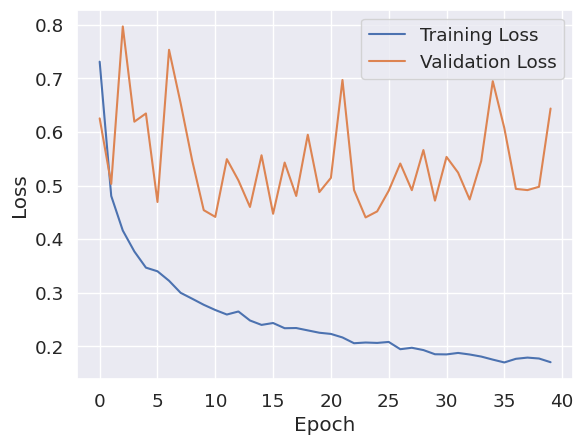

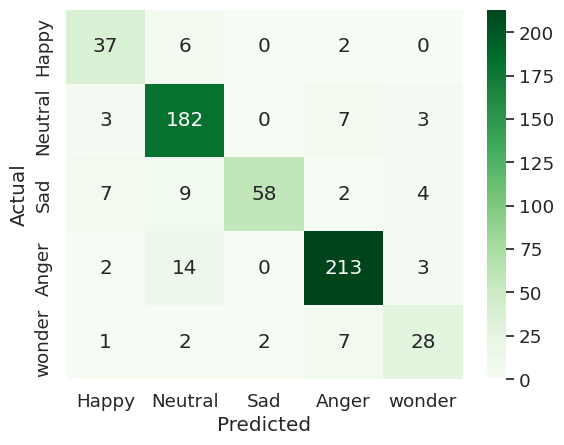

Testing finished with Loss:  0.44 | U_Accuracy:  0.82 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.87
Accuracy per class:
Class 0: 0.8222222222222222
Class 1: 0.9333333333333333
Class 2: 0.725
Class 3: 0.9181034482758621
Class 4: 0.7


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 265.25 seconds, Training Loss:  0.75, Validation Loss: 0.58, Validation Accuracy:  0.77


Epoch: 2 finished in 266.08 seconds, Training Loss:  0.49, Validation Loss: 0.67, Validation Accuracy:  0.77


Epoch: 3 finished in 266.25 seconds, Training Loss:  0.42, Validation Loss: 1.12, Validation Accuracy:  0.68


...

Epoch: 36 finished in 266.99 seconds, Training Loss:  0.18, Validation Loss: 0.70, Validation Accuracy:  0.83


Epoch: 37 finished in 267.27 seconds, Training Loss:  0.18, Validation Loss: 0.57, Validation Accuracy:  0.83


Epoch: 38 finished in 267.50 seconds, Training Loss:  0.18, Validation Loss: 0.59, Validation Accuracy:  0.83


Epoch: 39 finished in 266.88 seconds, Training Loss:  0.18, Validation Loss: 0.75, Validation Accuracy:  0.80


Epoch: 40 finished in 267.03 seconds, Training Loss:  0.17, Validation Loss: 0.56, Validation Accuracy:  0.84
Each epoch took 266.94 seconds in average.


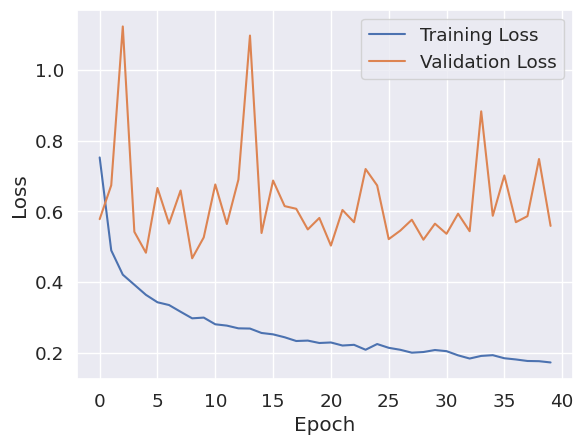

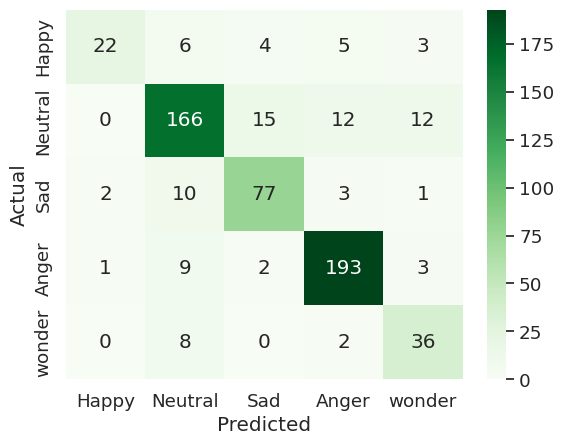

Testing finished with Loss:  0.47 | U_Accuracy:  0.78 | W_Accuracy:  0.83 | Precision:  0.84 | Recall:  0.83 | f1:  0.83
Accuracy per class:
Class 0: 0.55
Class 1: 0.8097560975609757
Class 2: 0.8279569892473119
Class 3: 0.9278846153846154
Class 4: 0.782608695652174


In [13]:
reset_seed(42)
counter = 1
loader_lists = []

for trainset_indices, trainset, valset in zip(folds_indices, folds_trains, folds_vals):
    audios_to_aug = [audio for (ind,audio) in enumerate(audios) if ind in trainset_indices]
    audio_gender_to_aug = [name[0] for (ind,name) in enumerate(file_names) if ind in trainset_indices]
    audio_emo_to_aug = [emotion for (ind,emotion) in enumerate(emotions) if ind in trainset_indices]

    segments ={}


    for emotion in ['H', 'W', 'S', 'A', 'N']:

        audiosF1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosF2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosM1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]
        audiosM2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]

        segments[emotion] = [(audiosF1, audiosF2), (audiosM1, audiosM2)]

    
    augmented_audios = []
    augmented_labels = []
    augmented_emotions = []

    augmentation_need = {
        'H': 9,
        'W': 9,
        'S': 4,
        'A': 1,
        'N': 1
        }
    
    for category in segments:
        for gender_segments in segments[category]:
            for audio in gender_segments[0]:
                choice = random.sample(gender_segments[1], augmentation_need[category])
                for ch in choice:
                    new_speech = np.concatenate((audio, ch))
                    augmented_audios.append(new_speech)
                    augmented_emotions.append(category)
                    augmented_labels.append(emo2num[category])


    augmented_samplerates = []
    augmeted_features = []


    for audio in augmented_audios:

        input_features = whisper_tiny_processor(audio, sampling_rate=16000, return_tensors="pt").input_features

        augmented_samplerates.append(16000)
        augmeted_features.append(input_features.squeeze(0))


    Aug = AudioDataSet(augmeted_features, augmented_labels, [' ']*len(augmeted_features), [' ']*len(augmeted_features))
    concatenated_dataset = ConcatDataset([trainset, Aug])


    train_loader = DataLoader(concatenated_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(valset, batch_size=4, shuffle=False)


    whisper_small_path = 'w_small'
    whisper_small = WhisperForAudioClassification.from_pretrained(
        whisper_small_path
    ).to(device)


    for param in whisper_small.parameters():
        param.requires_grad = False

    for param in whisper_small.projector.parameters():
        param.requires_grad = True

    whisper_small.classifier = torch.nn.Linear(256, 5).to(device) # Changing the head to fit our data and problem

    optimizer = torch.optim.Adam(whisper_small.parameters(), lr=0.001)

    training_losses1, valid_losses1 = train(whisper_small, f'whisper_small_aug_fold{counter}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)
    

    plt.plot(training_losses1, label='Training Loss')
    plt.plot(valid_losses1, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_small.load_state_dict(torch.load(f'whisper_small_aug_fold{counter}.bin'))
    test(whisper_small, torch.nn.CrossEntropyLoss(), val_loader)
    counter += 1

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 790.60 seconds, Training Loss:  0.78, Validation Loss: 0.61, Validation Accuracy:  0.80


Epoch: 2 finished in 792.07 seconds, Training Loss:  0.47, Validation Loss: 0.46, Validation Accuracy:  0.84


Epoch: 3 finished in 791.70 seconds, Training Loss:  0.41, Validation Loss: 0.55, Validation Accuracy:  0.81


Epoch: 4 finished in 795.11 seconds, Training Loss:  0.37, Validation Loss: 0.51, Validation Accuracy:  0.82


...

Epoch: 36 finished in 793.24 seconds, Training Loss:  0.16, Validation Loss: 0.58, Validation Accuracy:  0.84


Epoch: 37 finished in 793.54 seconds, Training Loss:  0.16, Validation Loss: 0.43, Validation Accuracy:  0.88


Epoch: 38 finished in 793.11 seconds, Training Loss:  0.15, Validation Loss: 0.48, Validation Accuracy:  0.87


Epoch: 39 finished in 793.85 seconds, Training Loss:  0.15, Validation Loss: 0.45, Validation Accuracy:  0.87


Epoch: 40 finished in 793.37 seconds, Training Loss:  0.15, Validation Loss: 0.46, Validation Accuracy:  0.84
Each epoch took 793.34 seconds in average.


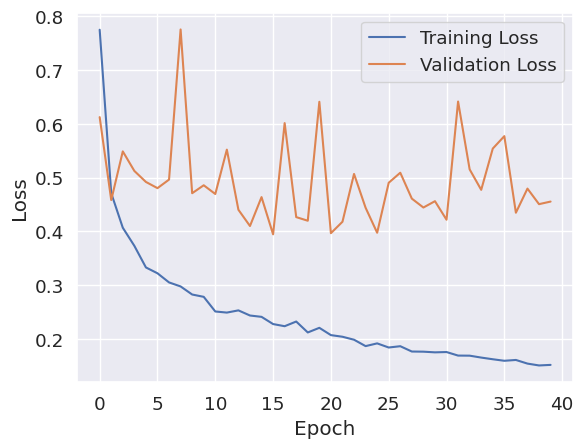

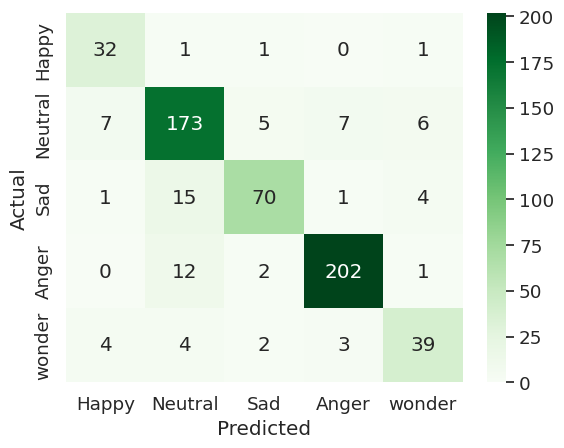

Testing finished with Loss:  0.39 | U_Accuracy:  0.85 | W_Accuracy:  0.87 | Precision:  0.87 | Recall:  0.87 | f1:  0.87
Accuracy per class:
Class 0: 0.9142857142857143
Class 1: 0.8737373737373737
Class 2: 0.7692307692307693
Class 3: 0.9308755760368663
Class 4: 0.75


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 788.28 seconds, Training Loss:  0.77, Validation Loss: 0.71, Validation Accuracy:  0.76


Epoch: 2 finished in 790.34 seconds, Training Loss:  0.46, Validation Loss: 0.50, Validation Accuracy:  0.83


Epoch: 3 finished in 790.11 seconds, Training Loss:  0.39, Validation Loss: 0.49, Validation Accuracy:  0.85


...

Epoch: 36 finished in 791.67 seconds, Training Loss:  0.14, Validation Loss: 0.57, Validation Accuracy:  0.84


Epoch: 37 finished in 791.40 seconds, Training Loss:  0.14, Validation Loss: 0.71, Validation Accuracy:  0.83


Epoch: 38 finished in 791.57 seconds, Training Loss:  0.14, Validation Loss: 0.65, Validation Accuracy:  0.84


Epoch: 39 finished in 790.82 seconds, Training Loss:  0.13, Validation Loss: 0.70, Validation Accuracy:  0.80


Epoch: 40 finished in 790.91 seconds, Training Loss:  0.13, Validation Loss: 0.61, Validation Accuracy:  0.83
Each epoch took 790.99 seconds in average.


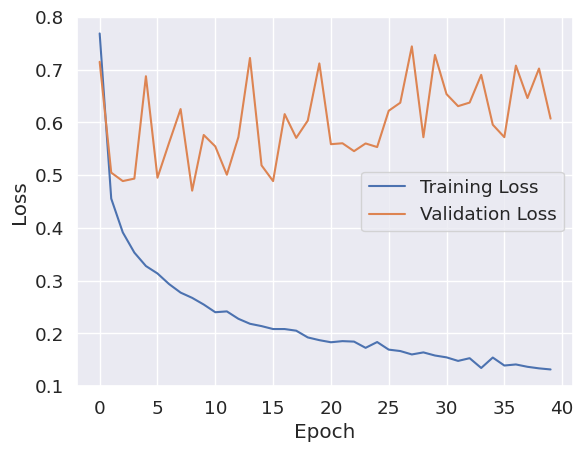

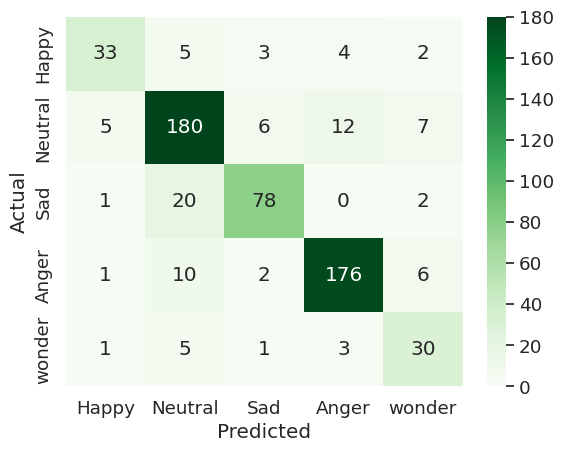

Testing finished with Loss:  0.47 | U_Accuracy:  0.80 | W_Accuracy:  0.84 | Precision:  0.84 | Recall:  0.84 | f1:  0.84
Accuracy per class:
Class 0: 0.7021276595744681
Class 1: 0.8571428571428571
Class 2: 0.7722772277227723
Class 3: 0.9025641025641026
Class 4: 0.75


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 797.28 seconds, Training Loss:  0.74, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 2 finished in 799.59 seconds, Training Loss:  0.45, Validation Loss: 0.70, Validation Accuracy:  0.78


Epoch: 3 finished in 799.57 seconds, Training Loss:  0.38, Validation Loss: 0.46, Validation Accuracy:  0.84


...

Epoch: 36 finished in 799.88 seconds, Training Loss:  0.14, Validation Loss: 0.60, Validation Accuracy:  0.87


Epoch: 37 finished in 800.19 seconds, Training Loss:  0.15, Validation Loss: 0.61, Validation Accuracy:  0.84


Epoch: 38 finished in 799.92 seconds, Training Loss:  0.15, Validation Loss: 0.60, Validation Accuracy:  0.85


Epoch: 39 finished in 799.33 seconds, Training Loss:  0.13, Validation Loss: 0.56, Validation Accuracy:  0.86


Epoch: 40 finished in 799.92 seconds, Training Loss:  0.13, Validation Loss: 0.62, Validation Accuracy:  0.85
Each epoch took 799.63 seconds in average.


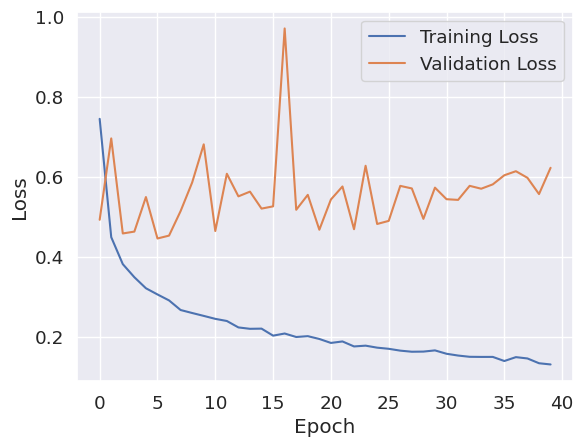

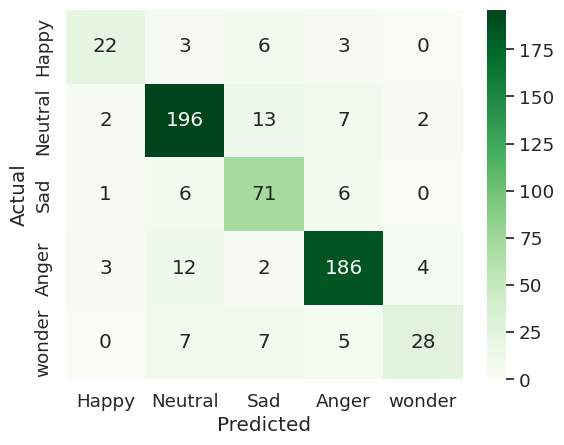

Testing finished with Loss:  0.45 | U_Accuracy:  0.78 | W_Accuracy:  0.85 | Precision:  0.85 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.6470588235294118
Class 1: 0.8909090909090909
Class 2: 0.8452380952380952
Class 3: 0.8985507246376812
Class 4: 0.5957446808510638


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 795.89 seconds, Training Loss:  0.76, Validation Loss: 0.59, Validation Accuracy:  0.79


Epoch: 2 finished in 798.18 seconds, Training Loss:  0.47, Validation Loss: 0.48, Validation Accuracy:  0.83


Epoch: 3 finished in 797.41 seconds, Training Loss:  0.39, Validation Loss: 0.55, Validation Accuracy:  0.82


...

Epoch: 36 finished in 797.72 seconds, Training Loss:  0.15, Validation Loss: 0.55, Validation Accuracy:  0.85


Epoch: 37 finished in 797.26 seconds, Training Loss:  0.16, Validation Loss: 0.56, Validation Accuracy:  0.86


Epoch: 38 finished in 797.41 seconds, Training Loss:  0.15, Validation Loss: 0.47, Validation Accuracy:  0.85


Epoch: 39 finished in 797.26 seconds, Training Loss:  0.15, Validation Loss: 0.52, Validation Accuracy:  0.83


Epoch: 40 finished in 797.05 seconds, Training Loss:  0.15, Validation Loss: 0.48, Validation Accuracy:  0.85
Each epoch took 797.56 seconds in average.


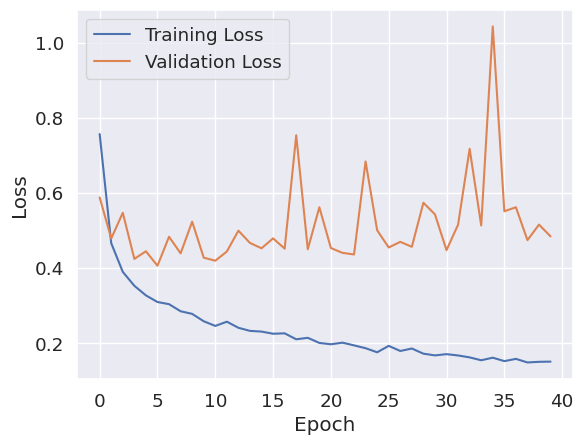

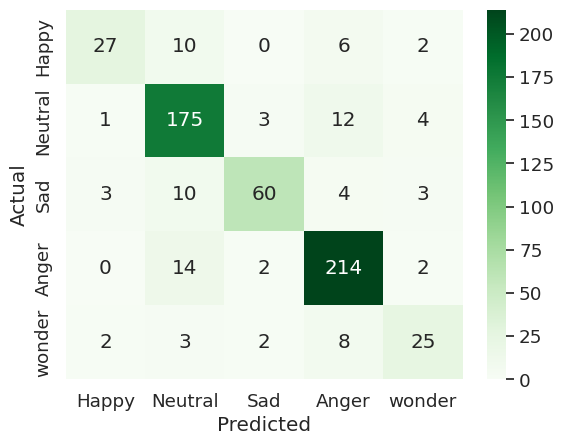

Testing finished with Loss:  0.41 | U_Accuracy:  0.76 | W_Accuracy:  0.85 | Precision:  0.85 | Recall:  0.85 | f1:  0.84
Accuracy per class:
Class 0: 0.6
Class 1: 0.8974358974358975
Class 2: 0.75
Class 3: 0.9224137931034483
Class 4: 0.625


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at w_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 790.41 seconds, Training Loss:  0.78, Validation Loss: 0.55, Validation Accuracy:  0.80


Epoch: 2 finished in 794.61 seconds, Training Loss:  0.46, Validation Loss: 0.65, Validation Accuracy:  0.79


Epoch: 3 finished in 793.48 seconds, Training Loss:  0.40, Validation Loss: 0.51, Validation Accuracy:  0.82


...

Epoch: 36 finished in 794.34 seconds, Training Loss:  0.14, Validation Loss: 0.54, Validation Accuracy:  0.85


Epoch: 37 finished in 794.34 seconds, Training Loss:  0.14, Validation Loss: 0.56, Validation Accuracy:  0.83


Epoch: 38 finished in 793.91 seconds, Training Loss:  0.15, Validation Loss: 0.56, Validation Accuracy:  0.84


Epoch: 39 finished in 793.75 seconds, Training Loss:  0.15, Validation Loss: 0.86, Validation Accuracy:  0.74


Epoch: 40 finished in 794.48 seconds, Training Loss:  0.13, Validation Loss: 0.60, Validation Accuracy:  0.84
Each epoch took 793.75 seconds in average.


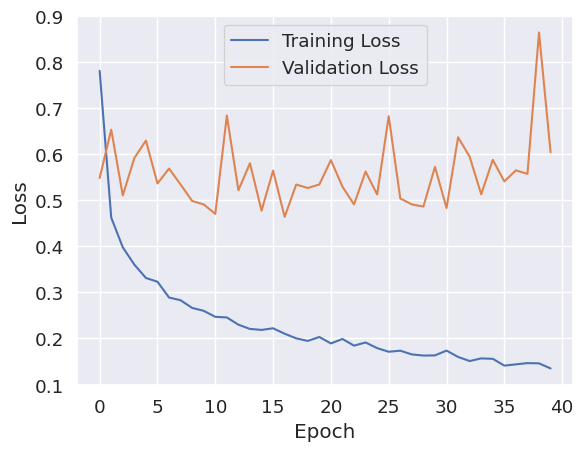

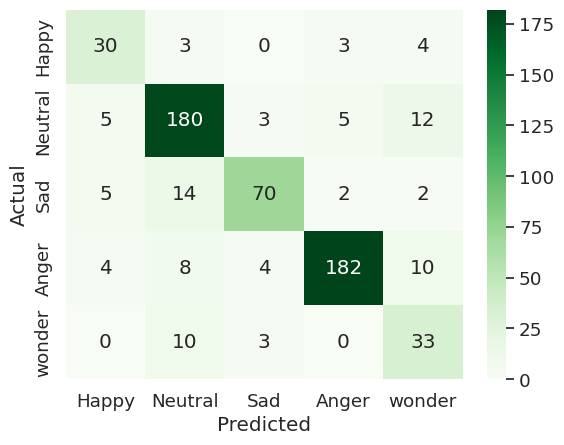

Testing finished with Loss:  0.46 | U_Accuracy:  0.79 | W_Accuracy:  0.84 | Precision:  0.85 | Recall:  0.84 | f1:  0.84
Accuracy per class:
Class 0: 0.75
Class 1: 0.8780487804878049
Class 2: 0.7526881720430108
Class 3: 0.875
Class 4: 0.717391304347826


In [14]:
reset_seed(42)
counter = 1
loader_lists = []

for trainset_indices, trainset, valset in zip(folds_indices, folds_trains, folds_vals):
    audios_to_aug = [audio for (ind,audio) in enumerate(audios) if ind in trainset_indices]
    audio_gender_to_aug = [name[0] for (ind,name) in enumerate(file_names) if ind in trainset_indices]
    audio_emo_to_aug = [emotion for (ind,emotion) in enumerate(emotions) if ind in trainset_indices]

    segments ={}


    for emotion in ['H', 'W', 'S', 'A', 'N']:

        audiosF1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosF2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosM1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]
        audiosM2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]

        segments[emotion] = [(audiosF1, audiosF2), (audiosM1, audiosM2)]

    
    augmented_audios = []
    augmented_labels = []
    augmented_emotions = []

    augmentation_need = {
        'H': 9,
        'W': 9,
        'S': 4,
        'A': 1,
        'N': 1
        }
    
    for category in segments:
        for gender_segments in segments[category]:
            for audio in gender_segments[0]:
                choice = random.sample(gender_segments[1], augmentation_need[category])
                for ch in choice:
                    new_speech = np.concatenate((audio, ch))
                    augmented_audios.append(new_speech)
                    augmented_emotions.append(category)
                    augmented_labels.append(emo2num[category])


    augmented_samplerates = []
    augmeted_features = []


    for audio in augmented_audios:

        input_features = whisper_tiny_processor(audio, sampling_rate=16000, return_tensors="pt").input_features

        augmented_samplerates.append(16000)
        augmeted_features.append(input_features.squeeze(0))


    Aug = AudioDataSet(augmeted_features, augmented_labels, [' ']*len(augmeted_features), [' ']*len(augmeted_features))
    concatenated_dataset = ConcatDataset([trainset, Aug])


    train_loader = DataLoader(concatenated_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(valset, batch_size=4, shuffle=False)


    whisper_small_path = 'w_medium'
    whisper_small = WhisperForAudioClassification.from_pretrained(
        whisper_small_path
    ).to(device)


    for param in whisper_small.parameters():
        param.requires_grad = False

    for param in whisper_small.projector.parameters():
        param.requires_grad = True

    whisper_small.classifier = torch.nn.Linear(256, 5).to(device) # Changing the head to fit our data and problem

    optimizer = torch.optim.Adam(whisper_small.parameters(), lr=0.0005)

    training_losses1, valid_losses1 = train(whisper_small, f'whisper_medium_aug_fold{counter}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

    plt.plot(training_losses1, label='Training Loss')
    plt.plot(valid_losses1, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_small.load_state_dict(torch.load(f'whisper_medium_aug_fold{counter}.bin'))
    test(whisper_small, torch.nn.CrossEntropyLoss(), val_loader)
    counter += 1